## Dataset Information

About Dataset
This comprehensive dataset includes every line from all of William Shakespeare’s plays, categorized by play, genre, character, and more. It is an invaluable resource for those interested in literary analysis, natural language processing, and the historical study of one of the most significant figures in English literature. The dataset consists of 108,093 rows and 9 columns, capturing lines from various plays by William Shakespeare. Here’s a breakdown of the dataset structure and its contents:

Columns:

1.play_name: The name of the play.

2.genre: The genre of the play (Comedy, History, Tragedy).

3.character: The character who delivers the line.

4.act: Act number in the play.

5.scene: Scene number in the act.

6.sentence: Line number in the scene.

7.text: The text of the dialogue.

8.sex: The gender of the character, reflecting Shakespeare's diverse cast.

Key Features:

-Detailed Line Entries: Over 100,000 lines of dialogue.

Rich Character Metadata: Lines are linked to over 950 unique characters, along with the character's sex, providing a deep dive into the 

sex dynamics within Shakespeare's works.

Potential Uses & Inspired Analysis:

Textual Analysis: Use natural language processing techniques to analyze Shakespeare’s language, themes, and character development.

Gender Studies: Explore the representation of gender across different plays and genres.

Educational Tools: Create educational content and analysis tools to help students and scholars understand Shakespeare’s work in depth.

Sentiment Analysis: Determine the sentiment of dialogues and how it varies across different types of plays and characters.

Topic Modeling: Identify prevalent themes and topics across different plays.

Network Analysis: Analyze interactions between characters to map out social networks within plays.


## Import Liabraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Connecting to google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [3]:
file_path = "/content/drive/MyDrive/Mini_GPT/data.txt"

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

print(len(text))

10084930


# Create Vocabulary

In [4]:
vocab = sorted(set(text))

char2idx = {u:i for i, u in enumerate(vocab)}
idx2char = {i:u for i, u in enumerate(vocab)}

vocab_size = len(vocab)

print("Vocab size:", vocab_size)

Vocab size: 79


Converts full dataset into numbers, and removed duplicates in the dataset.

Example:
Text: "hi"
Encoded: [7, 8]
Now model can understand it.

## Encode Text

In [5]:
text_as_int = np.array([char2idx[c] for c in text], dtype=np.int32)

## Create Training Sequences

In [6]:
seq_length = 64
batch_size = 16

dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

sequences = dataset.batch(seq_length + 1, drop_remainder=True)

def split_input_target(chunk):
    return chunk[:-1], chunk[1:]

dataset = sequences.map(split_input_target)

dataset = dataset.shuffle(10000).batch(batch_size, drop_remainder=True)

print(dataset)

<_BatchDataset element_spec=(TensorSpec(shape=(16, 64), dtype=tf.int32, name=None), TensorSpec(shape=(16, 64), dtype=tf.int32, name=None))>


through this GPT can predicts next token.  

If:
Input:
hello

Target:
ello

Shifted by one.

---



# Causal Mask


In [7]:
def create_causal_mask(seq_len):
    return tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)

It create full matrix.

tf.ones((4,4))

[[1,0,0,0],

[1,1,0,0],
      
[1,1,1,0],
    
[1,1,1,1]]


# Decoder Block

In [8]:
class DecoderBlock(layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super().__init__()

        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model
        )

        self.ffn = tf.keras.Sequential([
            layers.Dense(dff, activation="relu"),
            layers.Dense(d_model)
        ])

        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()

        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, x, training=False, mask=None):

        attn_output = self.attention(
            x, x,
            attention_mask=mask
        )

        attn_output = self.dropout1(attn_output, training=training)
        x = self.norm1(x + attn_output)

        ffn_output = self.ffn(x)
        ffn_output = self.dropout2(ffn_output, training=training)

        x = self.norm2(x + ffn_output)

        return x

this is a heart of GPT.

It looks at previous words (using masked self-attention), understands context, processes it through a small neural network, and outputs a better representation to predict the next word.

## Mini GPT Model

In [9]:
class MiniGPT(tf.keras.Model):
    def __init__(self, vocab_size, max_len,
                 num_layers=4,
                 d_model=256,
                 num_heads=8,
                 dff=512,
                 dropout=0.1):
        super().__init__()

        self.token_embedding = layers.Embedding(vocab_size, d_model)
        self.pos_embedding = layers.Embedding(max_len, d_model)

        self.decoder_blocks = [
            DecoderBlock(d_model, num_heads, dff, dropout)
            for _ in range(num_layers)
        ]

        self.norm = layers.LayerNormalization()
        self.final_dense = layers.Dense(vocab_size)

        self.max_len = max_len

    def call(self, x, training=False):

        seq_len = tf.shape(x)[1]

        positions = tf.range(start=0, limit=seq_len, delta=1)
        pos_embeddings = self.pos_embedding(positions)

        x = self.token_embedding(x)
        x = x + pos_embeddings

        mask = create_causal_mask(seq_len)

        for block in self.decoder_blocks:
            x = block(x, training=training, mask=mask)

        x = self.norm(x)
        logits = self.final_dense(x)

        return logits

Full GPT model

Inside constructor:

Token embedding

Positional embedding

Decoder blocks

Final dense layer

## Create Model

In [10]:
model = MiniGPT(
    vocab_size=vocab_size,
    max_len=seq_length
)

# Build model
dummy_input = tf.random.uniform((1, seq_length), maxval=vocab_size, dtype=tf.int32)
model(dummy_input)

model.summary()

Model: "mini_gpt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 64, 256)           │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (64, 256)              │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_block (DecoderBlock)    │ ?                      │     2,367,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_block_1 (DecoderBlock)  │ ?                      │     2,367,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_block_2 (DecoderBlock)  │ ?                      │     2,367,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_block_3 (DecoderBlock)  │ ?                      │     2,367,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_8           │ (1, 64, 256)           │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (1, 64, 79)            │        20,303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,527,375 (36.34 MB)

 Trainable params: 9,527,375 (36.34 MB)

 Non-trainable params: 0 (0.00 B)

# Compile & Train

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

history = model.fit(dataset, epochs=15)

Epoch 1/15
9697/9697 ━━━━━━━━━━━━━━━━━━━━ 341s 33ms/step - loss: 1.3356
Epoch 2/15
9697/9697 ━━━━━━━━━━━━━━━━━━━━ 334s 34ms/step - loss: 1.0475
Epoch 3/15
9697/9697 ━━━━━━━━━━━━━━━━━━━━ 335s 34ms/step - loss: 0.9969
Epoch 4/15
9697/9697 ━━━━━━━━━━━━━━━━━━━━ 336s 35ms/step - loss: 0.9695
Epoch 5/15
9697/9697 ━━━━━━━━━━━━━━━━━━━━ 333s 34ms/step - loss: 0.9527
Epoch 6/15
9697/9697 ━━━━━━━━━━━━━━━━━━━━ 331s 34ms/step - loss: 0.9384
Epoch 7/15
9697/9697 ━━━━━━━━━━━━━━━━━━━━ 334s 34ms/step - loss: 0.9289
Epoch 8/15
9697/9697 ━━━━━━━━━━━━━━━━━━━━ 334s 34ms/step - loss: 0.9214
Epoch 9/15
9697/9697 ━━━━━━━━━━━━━━━━━━━━ 337s 35ms/step - loss: 0.9140
Epoch 10/15
9697/9697 ━━━━━━━━━━━━━━━━━━━━ 335s 34ms/step - loss: 0.9103
Epoch 11/15
9697/9697 ━━━━━━━━━━━━━━━━━━━━ 342s 35ms/step - loss: 0.9025
Epoch 12/15
9697/9697 ━━━━━━━━━━━━━━━━━━━━ 341s 35ms/step - loss: 0.9033
Epoch 13/15
9697/9697 ━━━━━━━━━━━━━━━━━━━━ 337s 35ms/step - loss: 0.8973
Epoch 14/15
9697/9697 ━━━━━━━━━━━━━━━━━━━━ 337s 35ms/step - 

## Plot Loss

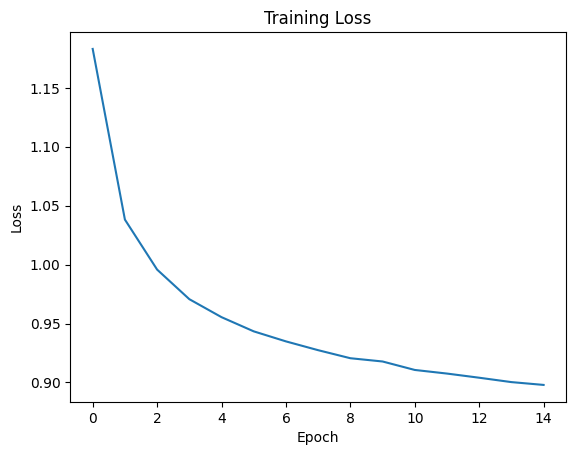

In [12]:
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Text Generation

In [13]:
def generate_text(start_string, length=200, temperature=1.0):

    input_eval = [char2idx[c] for c in start_string]
    input_eval = tf.expand_dims(input_eval, 0)

    generated = []

    for _ in range(length):

        predictions = model(input_eval)
        predictions = predictions[:, -1, :] / temperature

        predicted_id = tf.random.categorical(predictions, num_samples=1)[0][0].numpy()

        input_eval = tf.concat([input_eval, [[predicted_id]]], axis=1)
        input_eval = input_eval[:, -seq_length:]

        generated.append(idx2char[predicted_id])

    return start_string + ''.join(generated)


print(generate_text("The ", 200, temperature=0.5))

The faced some fortune,",male
107240,Titus Andronicus,Tragedy,Titus Andronicus,5,2,28,"I was in her honour of the death,",male
107014,Titus Andronicus,Tragedy,Titus Andronicus,4,3,12,That be so bound and 
